# Online Retail Store - Data Analysis Project

**Author:** Okunowo Oluwademilade David  
**Date:** July 2025  
**Tool:** Python (Pandas, Matplotlib, Seaborn)  
**Dataset:** UCI Online Retail Dataset — 392,692 transactions

## Imports & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("online_retail_cleaned.csv")
cancelled = pd.read_csv("online_retail_cancelled.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [4]:
invalid = [
    "Manual",
    "Postage",
    "Dotcom Postage",
    "Bank Charges",
    "Amazon Fee",
    "CRUK Commission",
]

df = df[~df["Description"].isin(invalid)]

In [5]:
print(f"Cleaned dataset shape:{df.shape}")
print(f"Cancelled dataset shape:{cancelled.shape}")

Cleaned dataset shape:(391286, 10)
Cancelled dataset shape:(8842, 8)


## Section 1: Revenue and Sales Trends

Month
2010-12     565749.560
2011-01     562882.910
2011-02     442493.590
2011-03     583843.850
2011-04     454840.881
2011-05     659678.490
2011-06     653764.920
2011-07     592103.791
2011-08     635864.380
2011-09     939652.631
2011-10    1003026.560
2011-11    1137634.000
2011-12     512378.080
Freq: M, Name: Revenue, dtype: float64


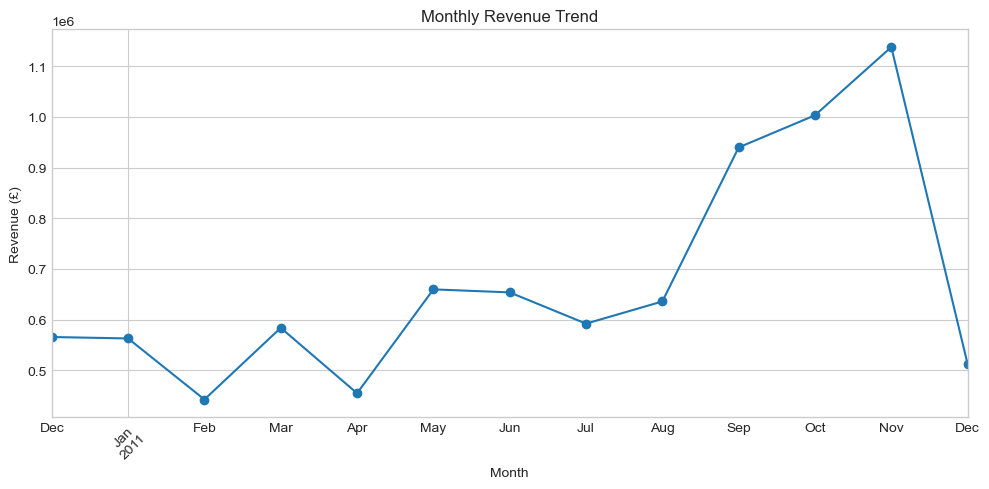

In [6]:
# Q1 → Is the business seasonal? Tracking monthly revenue helps size inventory and staffing around demand swings.
monthly_revenue = df.groupby("Month")["Revenue"].sum().sort_index()
print(monthly_revenue)
plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Q2 → When were revenue's best and worst points, and by how much did they differ? 
#This shows how extreme the seasonal swing really is.
print(
    f"Highest Month Revenue:{monthly_revenue.idxmax()}->£{monthly_revenue.max():,.2f}"
)
print(f"Lowest Month Revenue:{monthly_revenue.idxmin()}->£{monthly_revenue.min():,.2f}")

Highest Month Revenue:2011-11->£1,137,634.00
Lowest Month Revenue:2011-02->£442,493.59


In [8]:
# Q3 →  What does a typical order look like — retail-sized baskets or bulk/wholesale buying?
order_value = df.groupby("InvoiceNo")["Revenue"].sum()
aov = order_value.mean()
print(f"average_order_value:£{aov:,.2f}")

average_order_value:£475.08


### Section 1 Findings

- **February 2011 was the weakest month at £442,493** — consistent 
with typical post-Christmas retail slowdown following the December 
2010 holiday period.

- Revenue recovered steadily through the year before peaking in 
**November 2011 at £1,137,634** — more than double the February 
low and driven by early Christmas gifting demand in the weeks 
leading up to December 2011.

- The **Average Order Value of £475.08** suggests customers typically 
place medium-to-large basket size orders, indicating potential 
wholesale or bulk buying behaviour rather than purely retail.

- December 2011 shows a sharp drop to £512,378 — this is likely 
an **incomplete month** in the dataset rather than a genuine 
revenue decline.

## Section 2: Product Performance

Description
Paper Craft , Little Birdie           168469.60
Regency Cakestand 3 Tier              142264.75
White Hanging Heart T-Light Holder    100392.10
Jumbo Bag Red Retrospot                85040.54
Medium Ceramic Top Storage Jar         81416.73
Party Bunting                          68785.23
Assorted Colour Bird Ornament          56413.03
Rabbit Night Light                     51251.24
Chilli Lights                          46265.11
Paper Chain Kit 50'S Christmas         42584.13
Name: Revenue, dtype: float64


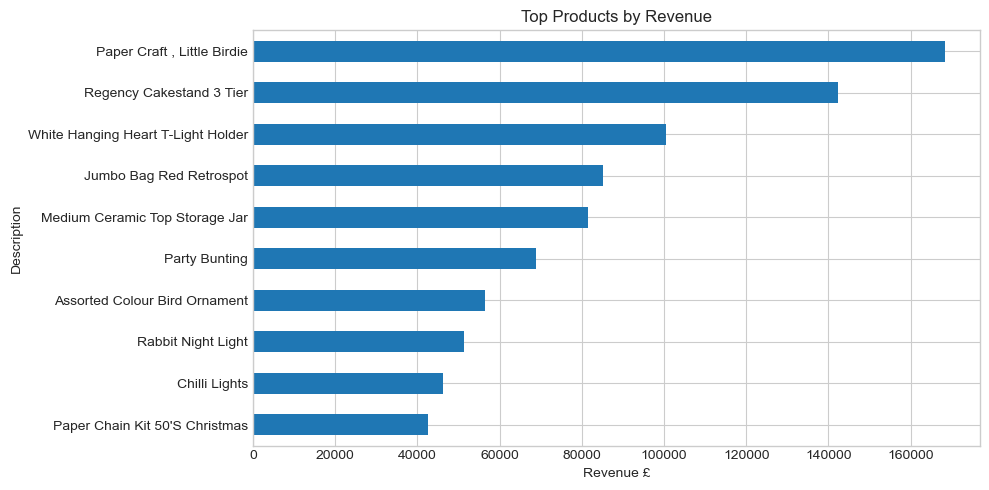

In [9]:
# Q4 → Which products generate the most revenue, and should they be prioritised for stock and marketing focus?
top_products_revenue = (
    df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
)
print(top_products_revenue)
plt.figure(figsize=(10, 5))
top_products_revenue.sort_values().plot(kind="barh")
plt.title("Top Products by Revenue")
plt.xlabel("Revenue £")
plt.tight_layout()
plt.show()

Description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        77916
World War 2 Gliders Asstd Designs     54319
Jumbo Bag Red Retrospot               46078
White Hanging Heart T-Light Holder    36706
Assorted Colour Bird Ornament         35263
Pack Of 72 Retrospot Cake Cases       33670
Popcorn Holder                        30919
Rabbit Night Light                    27153
Mini Paint Set Vintage                26076
Name: Quantity, dtype: int64


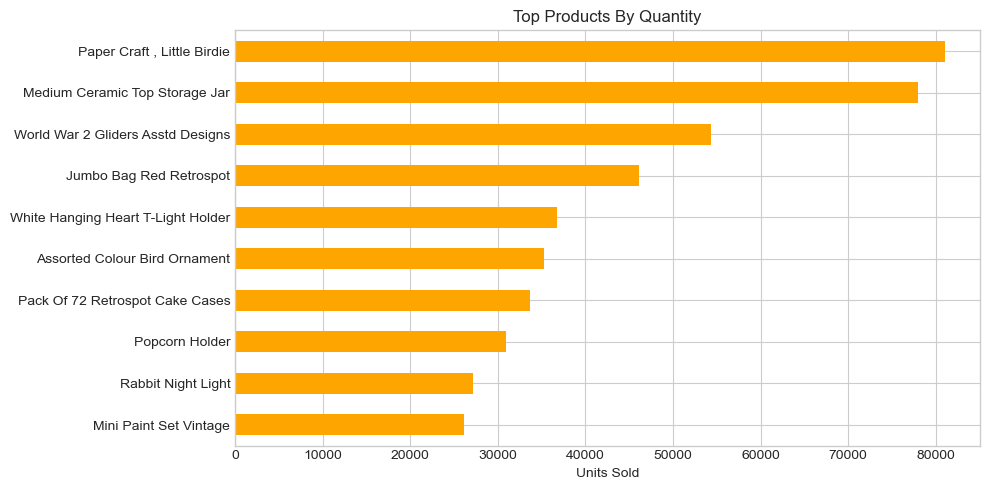

In [10]:
# Q5 → Which products sell the most units? Comparing this to the  revenue leaders shows whether volume and value are driven by the
# same products or different ones.
top_products_quantity = (
    df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
)
print(top_products_quantity)
plt.figure(figsize=(10, 5))
top_products_quantity.sort_values().plot(kind="barh", color="orange")
plt.title("Top Products By Quantity")
plt.xlabel("Units Sold")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [11]:
# Q6 → How much overlap is there between top-revenue and top-quantity products?
#Low overlap points to pricing/margin opportunities.
overlap = set(top_products_revenue.index) & set(top_products_quantity.index)
print(f"Products appearing in both lists:{len(overlap)}")
print(overlap)

Products appearing in both lists:6
{'White Hanging Heart T-Light Holder', 'Assorted Colour Bird Ornament', 'Paper Craft , Little Birdie', 'Rabbit Night Light', 'Jumbo Bag Red Retrospot', 'Medium Ceramic Top Storage Jar'}


### Section 2 Findings

- **Paper Craft, Little Birdie** is the standout product — ranking 
1st by both revenue (£168,469) and quantity sold (80,995 units), 
making it the single most important SKU in the entire catalogue.

- **Regency Cakestand 3 Tier** ranks 2nd by revenue at £142,264 
but does not appear in the top 10 by quantity — indicating it is 
a **premium priced product** selling in lower volumes at higher margins.

- **World War 2 Gliders Asstd Designs** ranks 3rd by quantity at 
54,319 units but does not appear in the revenue top 10 — suggesting 
it is a **low price high volume** product with thin margins.

- **6 out of 10 products appear in both lists** — confirming that 
the majority of bestsellers drive value through both volume and price, 
not just one dimension.

- 4 products appear in only one list — representing an opportunity 
to either **increase prices on high-volume low-revenue items** or 
**promote high-revenue low-volume items** more aggressively to 
drive units.

## Section 3: Customer Analysis

In [12]:
# Q7: How large and how loyal is the customer base?
unique_customers = df["CustomerID"].nunique()
print(f" Unique Customers: {unique_customers}")

 Unique Customers: 4334


 One Time Buyers: 1505(34.7%)
 Repeat Buyers: 2829(65.3%)


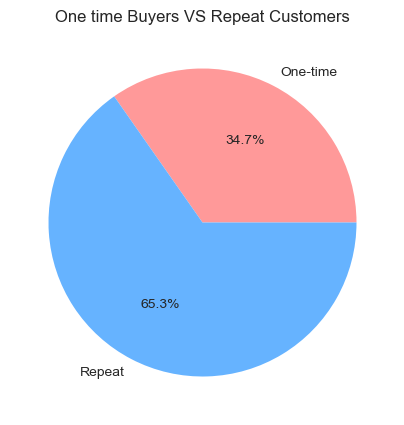

In [13]:
# Q8 → How much of the customer base comes back to buy again? A high
# one-time-buyer rate signals a retention/post-purchase problem worth solving
customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()
one_time_buyers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()
print(
    f" One Time Buyers: {one_time_buyers}({one_time_buyers/unique_customers*100:.1f}%)"
)
print(
    f" Repeat Buyers: {repeat_customers}({repeat_customers/unique_customers*100:.1f}%)"
)
plt.figure(figsize=(5, 5))
plt.pie(
    [one_time_buyers, repeat_customers],
    labels=["One-time", "Repeat"],
    autopct="%1.1f%%",
    colors=["#ff9999", "#66b3ff"],
)
plt.title("One time Buyers VS Repeat Customers")
plt.show()

CustomerID
14646    279138.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    140336.83
12415    124564.53
14156    117210.08
17511     91062.38
12346     77183.60
16029     72708.09
Name: Revenue, dtype: float64


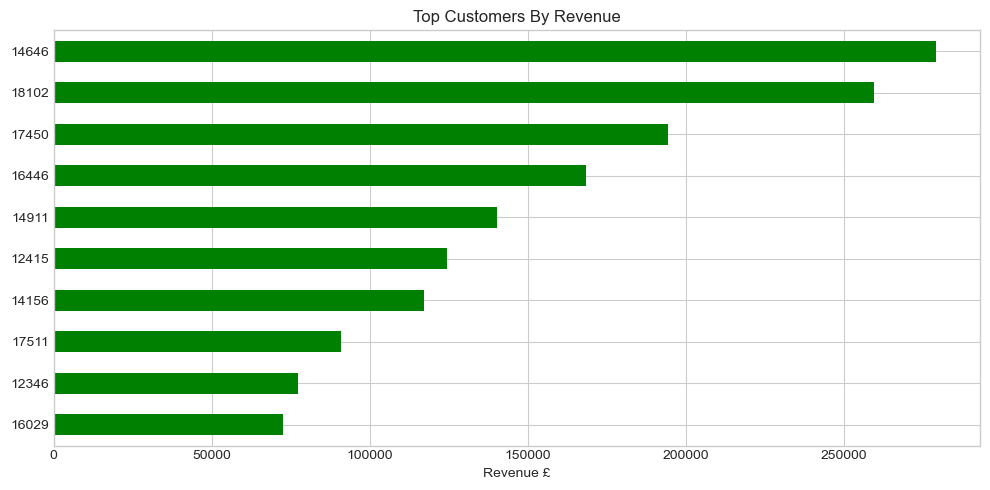

In [14]:
# Q9 → Who are the highest-value customers, and how concentrated is
# revenue among them? Heavy concentration is a business risk if any leave.
top_customers_revenue = (
    df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
)
print(top_customers_revenue)
plt.figure(figsize=(10, 5))
top_customers_revenue.sort_values().plot(kind="barh", color="green")
plt.title("Top Customers By Revenue")
plt.xlabel("Revenue £")
plt.ylabel("")
plt.tight_layout()
plt.show()

Segment
Loyal        2070
Others       1442
At Risk       818
Champions       4
Name: count, dtype: int64


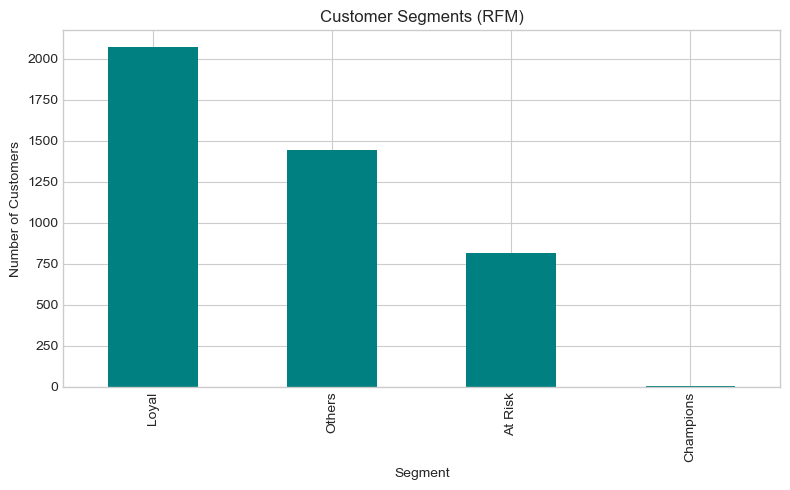

In [15]:
# Q10 → How can customers be segmented by how recently, how often, and
# how much they buy (RFM), so the business can target retention efforts
# where they matter most (e.g. at-risk vs loyal customers)?
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    {
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "Revenue": "sum",
    }
)
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm["R_Score"] = pd.cut(rfm["Recency"], 4, labels=[4, 3, 2, 1])
rfm["F_Score"] = pd.cut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.cut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
)


def segment_customer(row):
    if row["RFM_Score"] in ["444", "434", "443"]:
        return "Champions"
    elif row["R_Score"] in [4, 3] and row["F_Score"] in [3, 4]:
        return "Loyal"
    elif row["R_Score"] in [1, 2]:
        return "At Risk"
    else:
        return "Others"


rfm["Segment"] = rfm.apply(segment_customer, axis=1)
print(rfm["Segment"].value_counts())

plt.figure(figsize=(8, 5))
rfm["Segment"].value_counts().plot(kind="bar", color="teal")
plt.title("Customer Segments (RFM)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Section 3 Findings — Customer Analysis

- The dataset contains **4,334 unique customers** across the full year.

- **65.3% of customers (2,829) are repeat buyers** — meaning nearly 
2 in 3 customers returned to buy more than once. This is a positive 
signal of baseline customer loyalty.

- However **34.7% (1,505 customers) are one-time buyers** — over 
1 in 3 customers never returned after their first purchase. 
This represents significant lost lifetime value and suggests 
a post-purchase retention gap.

- **RFM segmentation reveals only 4 Champions** out of 4,334 customers 
(0.09%) — indicating the business has very few customers who are 
simultaneously recent, frequent and high spending.

- **2,070 customers (47.7%) are Loyal** — the largest and most 
important segment. These customers buy regularly and are the 
backbone of the business revenue.

- **818 customers (18.9%) are At Risk** — they purchased historically 
but have not bought recently and are likely to churn without 
targeted intervention.

- **Customer 14646 is the single highest value customer at £279,138** 
— nearly 4x more than the 10th highest spender (£72,708). This 
level of concentration in one customer represents a notable 
business risk.

## Section 4: Geographic Analysis

Country
United Kingdom    7244330.323
Netherlands        283889.340
Eire               261888.120
Germany            205381.150
France             183987.940
Australia          138103.810
Spain               55706.560
Switzerland         52441.950
Japan               37416.370
Belgium             36927.340
Name: Revenue, dtype: float64


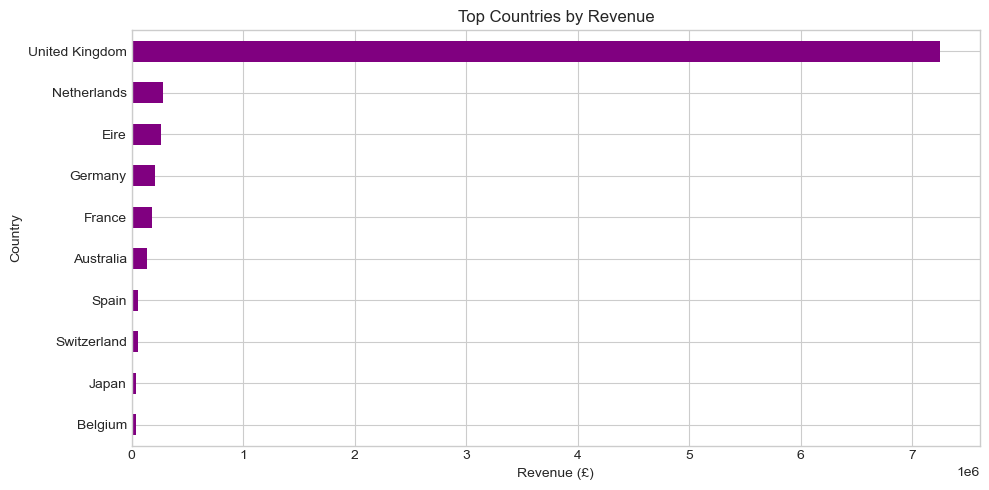

In [16]:
# Q11 → Which countries drive the most revenue, and how dependent is
# the business on any single market?
top_countries_revenue = (
    df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
)
print(top_countries_revenue)
plt.figure(figsize=(10, 5))
top_countries_revenue.sort_values().plot(kind="barh", color="purple")
plt.title("Top Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [17]:
# Q12 → Are there markets with a lot of order volume but low revenue
# per order? That could signal pricing misalignment or an underserved
# premium opportunity elsewhere.
country_summary = df.groupby("Country").agg(
    Orders=("InvoiceNo", "nunique"), Revenue=("Revenue", "sum")
)
country_summary["Revenue_per_Order"] = (
    country_summary["Revenue"] / country_summary["Orders"]
)
print(country_summary.sort_values("Revenue_per_Order").head(20))

                    Orders      Revenue  Revenue_per_Order
Country                                                   
Saudi Arabia             1      145.920         145.920000
Bahrain                  2      548.400         274.200000
Unspecified              8     2660.770         332.596250
Poland                  19     6974.650         367.086842
Belgium                 98    36927.340         376.809592
European Community       3     1159.250         386.416667
Czech Republic           2      786.740         393.370000
Malta                    5     2070.590         414.118000
Lithuania                4     1661.060         415.265000
United Kingdom       16579  7244330.323         436.958220
Italy                   35    15820.240         452.006857
Finland                 40    18344.880         458.622000
Germany                443   205381.150         463.614334
France                 380   183987.940         484.178789
Austria                 17     8742.680         514.2752

### Section 4 Findings — Geographic Analysis

- **United Kingdom dominates with £7,244,330** — representing 82.9% 
of total revenue. The business is heavily dependent on one market.

- **USA generates the highest revenue per order at £716** — despite 
only 5 orders, American customers spend significantly more per 
transaction than any other market, suggesting strong potential 
for targeted US expansion.

- **Belgium underperforms relative to order volume** — 98 orders 
at only £376 per order, below the UK baseline of £436, suggesting 
a product mix or pricing misalignment in that market.

- **Unspecified country appears with 8 orders** — representing 
a data collection gap where customer country was not recorded 
at point of sale.

## Section 5: Return Analysis

In [18]:
# Q13 → What share of orders end up cancelled/returned, and how does
# that compare to typical retail benchmarks (8–10%)?
total_orders = df["InvoiceNo"].nunique() + cancelled["InvoiceNo"].nunique()
cancelled_orders = cancelled["InvoiceNo"].nunique()
return_rate = cancelled_orders / total_orders * 100
print(f"Total completed orders: {df['InvoiceNo'].nunique()}")
print(f"Total cancelled orders: {cancelled_orders}")
print(f"Return rate: {return_rate:.2f}%")

Total completed orders: 18405
Total cancelled orders: 3502
Return rate: 15.99%


Description
Rotating Silver Angels T-Light Hldr    9376
Fairy Cake Flannel Assorted Colour     3150
Pink Blue Felt Craft Trinket Box       2617
White Hanging Heart T-Light Holder     2578
Gin + Tonic Diet Metal Sign            2030
Herb Marker Basil                      1527
Feltcraft Doll Molly                   1447
Tea Time Party Bunting                 1424
Paper Pocket Traveling Fan             1385
World War 2 Gliders Asstd Designs      1200
Name: Quantity, dtype: int64


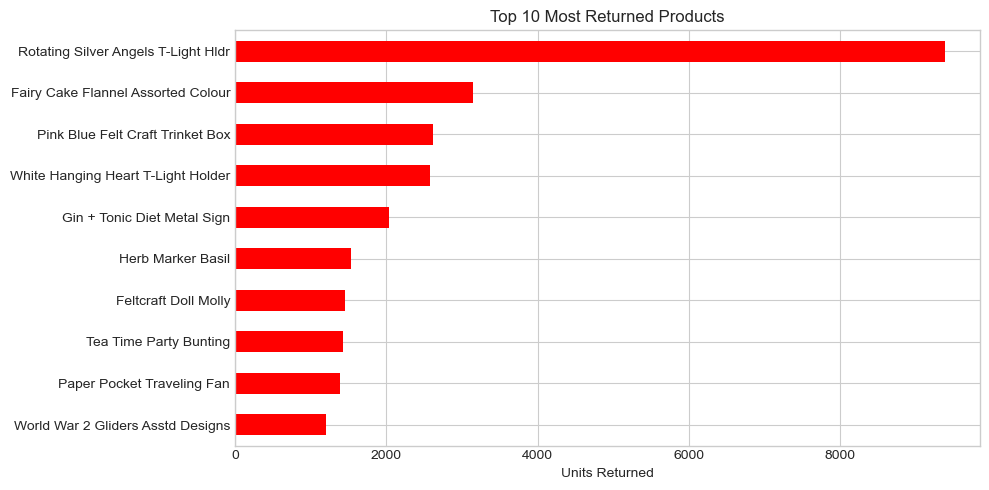

In [19]:
# Q14 → Which specific products drive the most returns? A product
# heavily overrepresented here may have a quality or listing-accuracy issue.
top_products_returned = (
    cancelled.groupby("Description")["Quantity"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_returned)
plt.figure(figsize=(10, 5))
top_products_returned.sort_values().plot(kind="barh", color="red")
plt.title("Top 10 Most Returned Products")
plt.xlabel("Units Returned")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Section 5 Findings — Returns Analysis

- The overall return rate is **15.99%** — significantly above the 
retail industry average of 8-10%, suggesting either product quality 
issues, customer expectation mismatches, or fulfilment errors.

- **Rotating Silver Angels T-Light Hldr is the most returned product 
at 9,376 units** — nearly 3x more than the second highest returned 
product (Fairy Cake Flannel at 3,150). This outlier warrants urgent 
product quality investigation.

- **White Hanging Heart T-Light Holder appears in top revenue, 
top quantity sold AND top returned** — it is the most cross-dimensional 
product in the dataset. While it drives significant revenue, its 
return volume suggests a potential quality or description mismatch 
issue that could be eroding profitability.

- **World War 2 Gliders Asstd Designs appears in both top quantity 
sold and top returned** — high volume in both directions suggests 
this is a low-price impulse product with high dissatisfaction rate.

- One anomalous cancellation record of 80,995 units for Paper Craft, 
Little Birdie was identified and excluded from returns analysis as 
it likely represents a system correction rather than a genuine 
customer return.CRUK Commission entries were also excluded from cancellation 
records as they represent charity commission fees rather than 
genuine customer product returns.

## Key Findings

1. **Revenue is highly seasonal** — November 2011 was the strongest 
month at £1,137,634, more than double the February low of £442,493. 
The business is heavily Q4 dependent.

2. **Paper Craft, Little Birdie is the star product** — ranking 1st 
by both revenue (£168,469) and quantity (80,995 units). Regency 
Cakestand 3 Tier is a hidden premium product — 2nd by revenue 
but absent from the quantity top 10.

3. **Customer loyalty is shallow** — only 4 Champions exist across 
4,334 customers. 34.7% of customers never returned after their 
first purchase and 818 are At Risk of churning permanently.

4. **The business is 83% dependent on the UK** — but the USA shows 
the highest revenue per order at £716, suggesting untapped 
international premium demand.

5. **The return rate of 15.99% is above industry average** — 
Rotating Silver Angels T-Light Hldr alone accounts for 9,376 
returned units, nearly 3x more than any other product.